# Recipe 2 — Extract Overlaps from Specific Tracks

This notebook walks through querying the FILER overlaps endpoint to pull the actual genomic
features (peaks, intervals, etc.) from a set of tracks that fall within a region of interest.

**What you'll learn:**
- How to query the FILER overlaps endpoint with a region and track ID list
- How to load track IDs directly or from a Recipe 1 `tracks.tsv` / `.trackset.json`
- How to explore and summarize the returned intervals
- How to save results as TSV and JSON for downstream workflows

**Use when:** you have a small-to-medium set of tracks from Recipe 1 and want the actual
intervals overlapping a locus. Expect ~1–2 seconds per batch of 250 tracks.

**Next steps after this notebook:**
- `01_track_discovery.ipynb` — find and filter tracks before querying
- `03_coordinate_search.ipynb` — discover tracks by region without a pre-selected ID list

Run the following before starting:
```
pip install -e ".[dev]"
```

---
## 0. Setup

In [27]:
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone
from filerpy.client import fetch_overlaps, load_ids_from_file, ENDPOINTS

In [28]:
print(f"FILER overlaps endpoint: {ENDPOINTS['overlaps']}")

FILER overlaps endpoint: https://tf.lisanwanglab.org/FILER2/get_overlaps.php


---
## 1. Hello World — query a region against two known tracks

The fastest way to verify your connection. `fetch_overlaps` handles batching and
error checking automatically and returns a flat DataFrame.

In [29]:
df_hello = fetch_overlaps(
    region="chr19:44905791-44909393",
    ids=["NGBLPL2W2SM2WC", "NGENCC4CIT5FBQ"],
)

In [30]:
print(f"Intervals returned: {len(df_hello)}")
print(df_hello.head().to_string())

Intervals returned: 5
       Identifier              queryRegion  chrom  chromStart  chromEnd                                                 name   score strand  signalValue     pValue     qValue    peak
0  NGBLPL2W2SM2WC  chr19:44905791-44909393  chr19    44906965  44910985  GC_T14_11.hyper_meth.bs_call.GRCh38.20150707_656194     NaN    NaN          NaN        NaN        NaN     NaN
1  NGENCC4CIT5FBQ  chr19:44905791-44909393  chr19    44905261  44906731                                          Peak_166852   200.0      .      2.00740   20.09425   18.16041   983.0
2  NGENCC4CIT5FBQ  chr19:44905791-44909393  chr19    44905261  44906731                                           Peak_47929  1000.0      .      4.28511  138.50365  135.95485   401.0
3  NGENCC4CIT5FBQ  chr19:44905791-44909393  chr19    44905261  44906731                                           Peak_71166   837.0      .      3.27742   83.75295   81.40279  1281.0
4  NGENCC4CIT5FBQ  chr19:44905791-44909393  chr19    44905261  

---
## 2. Configure your query

Set your region and choose how to supply track IDs.

| Source | When to use |
|---|---|
| `TRACK_IDS` list | A handful of known IDs |
| `TRACKS_FILE` path | Output from Recipe 1 — recommended for larger searches |

If both are set, `TRACK_IDS` takes precedence.

In [31]:
# ── Edit these parameters to match your use case ───────────────────────────
REGION     = "chr19:44905791-44909393"             # required; format: chrN:start-end

In [32]:
# Option A: supply IDs directly (takes precedence over TRACKS_FILE)
TRACK_IDS  = ["NGBLPL2W2SM2WC", "NGENCC4CIT5FBQ"]  # set to [] to use TRACKS_FILE
TRACK_IDS  = []

In [33]:
# Option B: load IDs from a file — see section 2b
TRACKS_FILE = "../../output/01-track-discovery/tracks.tsv"          # e.g. "output/01-track-discovery/recipe01_tracks.tsv"
ID_COL      = "identifier"  # column name in the TSV; ignored for .json files

In [34]:
CHUNK_SIZE = 250    # IDs per request; lower to 100 if the server returns errors
SAVE_JSON  = True   # also write overlaps.json alongside overlaps.tsv
# ───────────────────────────────────────────────────────────────────────────

In [35]:
if TRACK_IDS:
    track_ids = list(TRACK_IDS)
    print(f"Using {len(track_ids)} IDs supplied directly")
elif TRACKS_FILE:
    print(f"TRACKS_FILE set — continue to section 2b to load IDs from: {TRACKS_FILE}")
    track_ids = []
else:
    print("No IDs configured — set TRACK_IDS or TRACKS_FILE above")
    track_ids = []

TRACKS_FILE set — continue to section 2b to load IDs from: ../../output/01-track-discovery/tracks.tsv


### 2b. Load track IDs from a file (recommended for large searches)

Uses `load_ids_from_file` from `filer_find_overlaps.py` — the same logic as the `--file` +
`--id-col` flags in the CLI script.

| File type | How IDs are extracted |
|---|---|
| `.tsv` | Read `ID_COL` column, drop nulls, deduplicate |
| `.json` | Parse as a JSON array of records, read `ID_COL` field |

> ℹ️ Skipped automatically when `TRACK_IDS` is non-empty.

In [36]:
if TRACK_IDS:
    print(f"TRACK_IDS is set — skipping file load ({len(track_ids)} direct IDs)")
elif TRACKS_FILE:
    # load_ids_from_file mirrors --file + --id-col from the CLI script.
    # It validates that the file exists and that ID_COL is present, and exits clearly on errors.
    track_ids = load_ids_from_file(TRACKS_FILE, ID_COL)
    print(f"Loaded {len(track_ids)} unique IDs from {TRACKS_FILE}")
    print(f"First 5 IDs: {track_ids[:5]}")
else:
    raise ValueError("Set either TRACK_IDS or TRACKS_FILE in section 2 before continuing")

Loaded 262 unique IDs from ../../output/01-track-discovery/tracks.tsv
First 5 IDs: ['NGENCD5BW3DYHL', 'NGENC4P2SI32WC', 'NGENCBSUTVYWJF', 'NGENC66BM46JXU', 'NGENCV5IZIJXNO']


In [37]:
print(f"\nRegion  : {REGION}")
print(f"Tracks  : {len(track_ids)}")
print(f"Batches : {-(-len(track_ids) // CHUNK_SIZE)} x {CHUNK_SIZE}")


Region  : chr19:44905791-44909393
Tracks  : 262
Batches : 2 x 250


---
## 3. Run the query

`fetch_overlaps` splits the ID list into batches of `CHUNK_SIZE`, issues one GET request
per batch, and concatenates the results into a single DataFrame.

> ⚠️ Expect roughly 1 minute per batch of 250 tracks

In [38]:
df = fetch_overlaps(REGION, track_ids, chunk_size=CHUNK_SIZE)

In [ ]:
print(f"\nTotal overlapping intervals: {len(df)}")
print(df.head().to_string())


Total overlapping intervals: 303
         Identifier              queryRegion  chrom  chromStart  chromEnd         name  score strand  signalValue      pValue      qValue  peak
0    NGENC4P2SI32WC  chr19:44905791-44909393  chr19    44905426  44906778   Peak_19975   1000      .      6.65331   154.80937   151.90424  1130
1    NGENC4P2SI32WC  chr19:44905791-44909393  chr19    44905426  44906778   Peak_51191    475      .      3.68249    47.53612    45.06363   371
2    NGENC4P2SI32WC  chr19:44905791-44909393  chr19    44905426  44906778   Peak_51885    466      .      3.65841    46.65372    44.18732   648
3    NGENCBSUTVYWJF  chr19:44905791-44909393  chr19    44906447  44906709  Peak_108452     97      .      4.28189     9.78753     7.67778   134
4    NGENC66BM46JXU  chr19:44905791-44909393  chr19    44905577  44906328  Peak_275780     67      .      2.13280     6.73343     5.12254   289
5    NGENCV5IZIJXNO  chr19:44905791-44909393  chr19    44905574  44905906  Peak_134109     96      .  

### 3a. View key columns only

In [ ]:
PREFERRED_COLS = ["Identifier", "queryRegion", "chrom", "name", "score"]
KEY_COLS = [c for c in PREFERRED_COLS if c in df.columns]

In [41]:
print(f"Displaying columns: {KEY_COLS}")
print(df[KEY_COLS].head(10).to_string())

Displaying columns: ['Identifier', 'queryRegion', 'chrom', 'name', 'score']
       Identifier              queryRegion  chrom         name  score
0  NGENC4P2SI32WC  chr19:44905791-44909393  chr19   Peak_19975   1000
1  NGENC4P2SI32WC  chr19:44905791-44909393  chr19   Peak_51191    475
2  NGENC4P2SI32WC  chr19:44905791-44909393  chr19   Peak_51885    466
3  NGENCBSUTVYWJF  chr19:44905791-44909393  chr19  Peak_108452     97
4  NGENC66BM46JXU  chr19:44905791-44909393  chr19  Peak_275780     67
5  NGENCV5IZIJXNO  chr19:44905791-44909393  chr19  Peak_134109     96
6  NGENCV5IZIJXNO  chr19:44905791-44909393  chr19   Peak_69183    405
7  NGENCI2BRRHFIY  chr19:44905791-44909393  chr19  Peak_137456    209
8  NGENCI2BRRHFIY  chr19:44905791-44909393  chr19   Peak_85115    656
9  NGENCXWF2UQUFB  chr19:44905791-44909393  chr19            .    550


---
## 4. Explore the results

In [42]:
print("=== Intervals per track (top 20) ===")
print(df["Identifier"].value_counts().head(20).to_string())

=== Intervals per track (top 20) ===
Identifier
NGENCCVBUDCSVQ    5
NGENCYHETUWGRL    5
NGENCFIJYCXB5D    5
NGENCC4CIT5FBQ    4
NGENCFVJ6WYVRS    4
NGENCKWHDKRPQS    4
NGENCURRQUMDZY    4
NGENCJR7SX2LV4    4
NGENC3CWVX66GC    4
NGENCEXQHP6QBJ    4
NGENCEVIZOQ3EP    4
NGENCWRKNQBTAH    4
NGENCDUEUI7G3U    4
NGENCHITVI2OS3    4
NGENC4NLKLDNY4    4
NGENCMBRVYIDDX    4
NGENCGLIXMFZFA    4
NGENCFPZIV4CGG    4
NGENCPGKYJIC5P    4
NGENCF2ISBSJZ2    4


In [43]:
if "score" in df.columns:
    print("=== Score distribution ===")
    print(df["score"].describe())

=== Score distribution ===
count     303.000000
mean      582.227723
std       394.881294
min        35.000000
25%       160.500000
50%       630.000000
75%      1000.000000
max      1000.000000
Name: score, dtype: float64


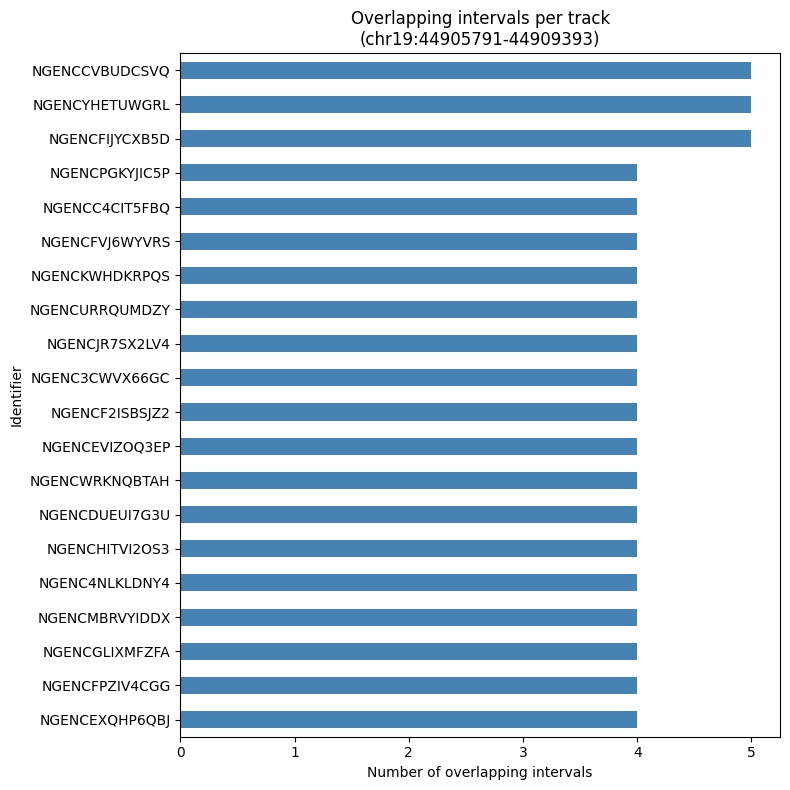

In [45]:
# Bar chart — intervals per track (top 20)
counts = df["Identifier"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, max(3, len(counts) * 0.4)))
counts.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Number of overlapping intervals")
ax.set_title(f"Overlapping intervals per track\n({REGION})")
plt.tight_layout()
plt.show()

In [46]:
# Histogram — interval lengths
if "interval_length" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    df["interval_length"].plot.hist(ax=ax, bins=40, color="orchid", edgecolor="white")
    ax.set_xlabel("Interval length (bp)")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of overlapping interval lengths\n({REGION})")
    plt.tight_layout()
    plt.show()

---
## 5. Refine your selection

Post-query filtering in pandas — useful for narrowing by score, interval length, or specific tracks.

In [47]:
df_filtered = df.copy()

In [48]:
# ── Edit these conditions to match what you need ────────────────────────────
if "score" in df_filtered.columns:
    df_filtered = df_filtered[df_filtered["score"].astype(float) > 0]

In [49]:
if "interval_length" in df_filtered.columns:
    df_filtered = df_filtered[df_filtered["interval_length"] >= 100]
# ─────────────────────────────────────────────────────────────────────────────

In [50]:
print(f"After refinement: {len(df_filtered)} intervals (from {len(df)} total)")
print(df_filtered[KEY_COLS].head().to_string())

After refinement: 303 intervals (from 303 total)
       Identifier              queryRegion  chrom         name  score
0  NGENC4P2SI32WC  chr19:44905791-44909393  chr19   Peak_19975   1000
1  NGENC4P2SI32WC  chr19:44905791-44909393  chr19   Peak_51191    475
2  NGENC4P2SI32WC  chr19:44905791-44909393  chr19   Peak_51885    466
3  NGENCBSUTVYWJF  chr19:44905791-44909393  chr19  Peak_108452     97
4  NGENC66BM46JXU  chr19:44905791-44909393  chr19  Peak_275780     67


---
## 6. Save results

### 6a. Save as TSV

In [51]:
repo_root = Path().resolve().parents[1]
out_dir = repo_root / "output" / "02-track-overlaps"
out_dir.mkdir(parents=True, exist_ok=True)

In [52]:
tsv_path = out_dir / "overlaps.tsv"
df_filtered.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved {len(df_filtered)} intervals -> {tsv_path}")

Saved 303 intervals -> /Users/divak2004/Documents/GitHub/FILER-workflows/output/02-track-overlaps/overlaps.tsv


### 6b. Save as JSON (optional)

In [53]:
if SAVE_JSON:
    json_path = out_dir / "overlaps.json"
    df_filtered.to_json(json_path, orient="records", indent=2)
    print(f"Saved JSON -> {json_path}")
else:
    print("SAVE_JSON=False — skipping JSON output")

Saved JSON -> /Users/divak2004/Documents/GitHub/FILER-workflows/output/02-track-overlaps/overlaps.json


### 6c. Save query provenance (recommended for reproducibility)

In [54]:
provenance = {
    "query": {
        "region":     REGION,
        "track_ids":  track_ids,
        "chunk_size": CHUNK_SIZE,
        "source":     TRACKS_FILE if TRACKS_FILE else "direct",
    },
    "results": {
        "total_intervals":  len(df),
        "after_refinement": len(df_filtered),
    },
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "endpoint":  ENDPOINT,
}

NameError: name 'ENDPOINT' is not defined

In [ ]:
prov_path = out_dir / "overlaps_provenance.json"
prov_path.write_text(json.dumps(provenance, indent=2))
print(f"Provenance saved -> {prov_path}")
print(json.dumps(provenance, indent=2))

---
## 7. Next steps

You now have `overlaps.tsv`, `overlaps.json`, and `overlaps_provenance.json` ready for
downstream use.

| What to do next | Recipe / Notebook |
|---|---|
| Find and filter tracks before querying | Recipe 1 / `01_track_discovery.ipynb` |
| Discover tracks by region without a pre-selected ID list | Recipe 3 / `03_coordinate_search.ipynb` |
| Summarize overlaps by assay / cell type | Recipe 4.1 |
| Deploy tracks locally for fast offline queries | Recipe 2.2 |

```python
# Quick reference: reload your saved results in a future session
import pandas as pd
df = pd.read_csv("output/02-track-overlaps/overlaps.tsv", sep="\t")
print(df.head())
```